# Quantum Pump BO Experiment — v6.3

## v6.2 → v6.3 추가 사항

### 추가 1: Phase 4 — 펌프맵 (6-panel, v5b fig3b 포맷)
- GP 기반 adaptive sampling (LHS → plateau-aware adaptive → dense refinement)
- 6패널: (a) dI/dV_exit 맵, (b) n 컬러맵, (c) ground-truth/GP uncertainty,
  (d) 오차맵 (log), (e) I-V_exit 곡선 다중, (f) |(I-ef)/ef| log 스케일 + Eq.(1) 피팅

### 추가 2: 실측 모드에서 V_p도 3D BO 탐색
- `cfg.V_P_SCAN_IN_HW = True` 설정 시 Phase 2 BO를 3D (V_ent, V_p, V_exit) 로 전환
- 시뮬레이션 모드: V_p 고정 (데이터가 V_p=0.2V 고정이므로)
- 실측 모드:       V_p 자유 탐색 (소자마다 최적 V_p가 다름)
- Rule No.1 유지

In [1]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from pathlib import Path
from datetime import datetime
import warnings
import pandas as pd
import time
import json
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.optimize import minimize
from scipy.stats import qmc

try:
    import pyvisa
    PYVISA_AVAILABLE = True
    print('✅ PyVISA imported')
except ImportError:
    PYVISA_AVAILABLE = False
    print('⚠️  PyVISA not available → Simulation mode')

print('Quantum Pump BO v6.3  |  2D/3D BO + 6-panel pump map')


✅ PyVISA imported
Quantum Pump BO v6.3  |  2D/3D BO + 6-panel pump map


In [2]:
# Cell 2: Configuration
class Config:
    # ===== 물리 상수 =====
    e = 1.60217663e-19
    f = 6.5e7

    @property
    def I_ref_nA(self):
        return self.e * self.f * 1e9   # ~0.01041 nA

    @property
    def I_ref_A(self):
        return self.e * self.f

    # ===== [설정 1] GPIB 주소 =====
    ADDR_YOKO_ENT  = 'GPIB43::1::INSTR'
    ADDR_YOKO_P    = 'GPIB43::2::INSTR'
    ADDR_YOKO_EXIT = 'GPIB43::8::INSTR'
    ADDR_DMM       = 'GPIB43::19::INSTR'

    # ===== [설정 2] 게인 =====
    GAIN_COARSE_A_PER_V = 1e-8
    GAIN_FINE_A_PER_V   = 1e-9

    # ===== [설정 3] V_p =====
    V_P_FIXED         = 0.20    # 시뮬레이션 & 실측 고정 모드에서 사용
    V_P_SCAN_IN_HW    = True    # True=실측 시 V_p도 3D BO 탐색
                                # False=실측에서도 V_p 고정
    V_P_HW_MIN        = 0.10    # 실측 V_p 탐색 하한
    V_P_HW_MAX        = 0.30    # 실측 V_p 탐색 상한

    # ===== [설정 4] BO 탐색 범위 =====
    BO_V_ENT_MIN  =  0.05
    BO_V_ENT_MAX  =  0.30
    BO_V_EXIT_MIN = -0.05
    BO_V_EXIT_MAX =  0.15

    # ===== [설정 5] 시뮬레이션 =====
    FORCE_SIMULATION = False
    SIM_DATA_PATH    = None    # Cell 9에서 설정

    # ===== 자동 설정 =====
    MAX_STEP_V    = 0.004
    SETTLING_TIME = 1.5
    DMM_NPLC      = 1.0

    # Phase1
    PINCH_SCAN_POINTS = 81
    PINCH_OFF_THR_A   = 5e-12

    # Phase2 BO
    BO_N_INIT              = 25
    BO_N_ITER              = 75
    BO_N_TOL               = 0.05
    BO_EARLY_STOP_PATIENCE = 20
    BO_KAPPA_INIT          = 2.0
    BO_KAPPA_MIN           = 0.5

    # Phase3 확인맵
    MAP_V_ENT_N    = 6
    MAP_V_EXIT_N   = 50
    MAP_V_EXIT_HALF= 0.07
    MAP_V_ENT_HALF = 0.10

    # Phase4 펌프맵
    PUMP_MAP_LHS          = 35    # LHS 초기 샘플
    PUMP_MAP_ADAPTIVE     = 65    # adaptive 샘플
    PUMP_MAP_GRID_RES     = 80    # GP 예측 그리드 해상도
    PUMP_MAP_V_ENT_HALF   = 0.12  # 맵 범위 ±V
    PUMP_MAP_V_EXIT_HALF  = 0.08
    PUMP_MAP_REFINE_LINES = 3     # dense refinement 라인 수
    PUMP_MAP_REFINE_SPAN  = 0.06  # refinement V_exit 범위
    PUMP_MAP_REFINE_STEP  = 0.002 # refinement 스텝
    PUMP_MAP_ACQ_W_UNCERT = 0.45
    PUMP_MAP_ACQ_W_LEVEL  = 0.45
    PUMP_MAP_ACQ_W_FLAT   = 0.10
    PUMP_MAP_ACQ_LEVELS   = (1.0, 2.0)
    PUMP_MAP_ACQ_TAU      = 0.10
    PUMP_MAP_ACQ_DV_FLAT  = 0.004
    PUMP_MAP_CURVE_OFFSETS= [-0.04, -0.02, 0.0, 0.02, 0.04]
    TC_CLIP_PERCENTILE    = 99.0

    output_dir = Path('./pump_bo_v6_3_output')

cfg = Config()
print(f'I_ref      = {cfg.I_ref_nA:.5f} nA')
print(f'V_p fixed  = {cfg.V_P_FIXED:.3f} V  (sim mode)')
print(f'V_p scan   = {cfg.V_P_SCAN_IN_HW}  (HW mode)')
print(f'BO V_exit  [{cfg.BO_V_EXIT_MIN:+.3f}, {cfg.BO_V_EXIT_MAX:+.3f}] V')
print('Config OK')


I_ref      = 0.01041 nA
V_p fixed  = 0.200 V  (sim mode)
V_p scan   = True  (HW mode)
BO V_exit  [-0.050, +0.150] V
Config OK


In [3]:
# Cell 3: Instrument Controller
# ※ v5b 검증 코드 기반 — Yokogawa 7651 + Keithley 2000 전용
#
# v6.3 → v6.3_hw 수정 사항 (v5b 대비 발견된 문제 수정):
#   [수정1] Yokogawa 명령: :SOURCE:LEVEL → S{V:.6f}E  (7651 전용)
#   [수정2] DMM 측정:      MEAS:VOLT:DC? → fetch?      (Keithley 전용)
#   [수정3] settling time: 스텝당 나눔 → 매 스텝 전체 대기
#   [수정4] 3채널 개별 순차 → 3채널 동시 선형 보간 stepwise
#   [수정5] termination / timeout 설정 추가
#   [수정6] NPLC 복수 후보 명령 시도 추가
#   [수정7] close() 메서드 추가
#   [수정8] DMM 전압에 부호 반전(-) 적용

class InstrumentController:
    """
    Rule No.1: 모든 전압 변화는 MAX_STEP_V 이하로 stepwise 인가.
    v5b 검증 하드웨어 코드 기반.
    """
    def __init__(self, config):
        self.cfg = config
        self.sim_mode = False
        self.gain = float(config.GAIN_COARSE_A_PER_V)
        self.current_voltages = {
            'V_ent':  0.0,
            'V_p':    float(config.V_P_FIXED),
            'V_exit': 0.0,
        }
        self._total_meas = 0

        if config.FORCE_SIMULATION:
            self.sim_mode = True
            self._init_sim()
            return
        if not PYVISA_AVAILABLE:
            print('⚠️  PyVISA not available → Simulation mode')
            self.sim_mode = True
            self._init_sim()
            return

        try:
            self.rm = pyvisa.ResourceManager()
            print('Connecting to instruments...')
            self.yoko_ent  = self.rm.open_resource(config.ADDR_YOKO_ENT)
            print(f'  ✅ G_ENT:  {config.ADDR_YOKO_ENT}')
            self.yoko_p    = self.rm.open_resource(config.ADDR_YOKO_P)
            print(f'  ✅ G_P:    {config.ADDR_YOKO_P}')
            self.yoko_exit = self.rm.open_resource(config.ADDR_YOKO_EXIT)
            print(f'  ✅ G_EXIT: {config.ADDR_YOKO_EXIT}')
            self.dmm       = self.rm.open_resource(config.ADDR_DMM)
            print(f'  ✅ DMM:    {config.ADDR_DMM}')
            self._configure_instruments()
            print()
            print('✅ HARDWARE MODE')
            print(f'   Gain: {self.gain:.0e} A/V')
            print(f'   MAX_STEP_V: {config.MAX_STEP_V*1000:.1f} mV')
            print(f'   SETTLING_TIME: {config.SETTLING_TIME*1000:.0f} ms/step')
        except Exception as e:
            print(f'\n⚠️  Hardware connection failed: {e}')
            print('   → Simulation mode')
            self.sim_mode = True
            self._init_sim()

    # ── [수정5][수정6] 하드웨어 초기화 (v5b 검증) ────────────────
    def _configure_instruments(self):
        # termination & timeout
        for inst in [self.yoko_ent, self.yoko_p, self.yoko_exit]:
            inst.write_termination = "\n"
            inst.read_termination  = "\n"
            inst.timeout = 5000
        self.dmm.write_termination = "\n"
        self.dmm.read_termination  = "\n"
        self.dmm.timeout = 10000

        # NPLC — 복수 후보 명령 순차 시도
        nplc = float(getattr(self.cfg, 'DMM_NPLC', 1.0))
        for cmd in [f'SENS:VOLT:DC:NPLC {nplc:g}',
                    f':SENS:VOLT:DC:NPLC {nplc:g}',
                    f'VOLT:DC:NPLC {nplc:g}']:
            try:
                self.dmm.write(cmd)
                print(f'  ✅ DMM NPLC={nplc:g}  '
                      f'(≈{nplc/60*1000:.0f}ms @ 60Hz)')
                break
            except Exception:
                continue
        else:
            print(f'  ⚠️  DMM NPLC 설정 실패 — 기기 SCPI 모드 확인 필요')

    # ── 시뮬레이션 초기화 ────────────────────────────────────────
    def _init_sim(self):
        self._sim_kind = 'analytic'
        path = self.cfg.SIM_DATA_PATH
        if path is None:
            print('⚠️  SIM_DATA_PATH 미설정 → Analytic model')
            return
        if not Path(path).exists():
            print(f'❌  파일 없음: {path} → Analytic model')
            return
        try:
            from scipy.interpolate import (LinearNDInterpolator,
                                            NearestNDInterpolator,
                                            RegularGridInterpolator)
            import pandas as _pd
            arr    = np.loadtxt(path)
            Ve     = arr[:, 0].astype(float)
            Vx     = arr[:, 1].astype(float)
            I_nA   = arr[:, 2].astype(float)
            mask   = np.isfinite(Ve) & np.isfinite(Vx) & np.isfinite(I_nA)
            Ve     = Ve[mask]; Vx = Vx[mask]; I_nA = I_nA[mask]
            n_vals = (I_nA * 1e-9) / (self.cfg.e * self.cfg.f)
            pts    = np.column_stack([Ve, Vx])
            self._interp_lin  = LinearNDInterpolator(pts, n_vals, fill_value=np.nan)
            self._interp_nn   = NearestNDInterpolator(pts, n_vals)
            self._interp_grid = None
            try:
                df = _pd.DataFrame({'a': Ve, 'b': Vx, 'n': n_vals})
                pv = (df.pivot_table(index='a', columns='b', values='n', aggfunc='mean')
                        .sort_index(axis=0).sort_index(axis=1))
                g  = pv.to_numpy(dtype=float)
                if not np.isnan(g).any() and g.size > 0:
                    self._interp_grid = RegularGridInterpolator(
                        (pv.index.to_numpy(float), pv.columns.to_numpy(float)),
                        g, bounds_error=False, fill_value=np.nan)
            except Exception:
                pass
            self._sim_kind = 'replay'
            print(f'✅  Replay loaded: {arr.shape[0]} pts')
            print(f'   V_ent  [{Ve.min():.3f}, {Ve.max():.3f}] V')
            print(f'   V_exit [{Vx.min():.3f}, {Vx.max():.3f}] V')
            print(f'   V_p 는 데이터에 없음 → V_p={self.cfg.V_P_FIXED:.3f}V 고정 해석')
        except Exception as ex:
            print(f'❌  로드 실패: {ex} → Analytic model')

    def _sim_measure(self, V_ent, V_p, V_exit):
        if self._sim_kind == 'replay':
            pt = np.array([[V_ent, V_exit]])
            n  = np.nan
            if self._interp_grid is not None:
                n = float(self._interp_grid([[V_ent, V_exit]]).ravel()[0])
            if np.isnan(n):
                n = float(self._interp_lin(pt).ravel()[0])
            if np.isnan(n):
                n = float(self._interp_nn(pt).ravel()[0])
            return float(n + np.random.normal(0, 3e-4))
        # Analytic fallback
        Vc  = -0.223 * V_ent + 0.087
        ph  = 0.011
        vps = max(0.05, min(1.0 + 3.0*(V_p - 0.20), 4.0))
        dv  = V_exit - Vc
        if   abs(dv) < ph:  nb = 1.0 + 0.4*(dv/ph)
        elif dv > ph:        nb = min(1.4 + 15.0*(dv-ph), 5.0)
        else:                nb = max(0.0, 1.0 + 2.0*dv/ph)
        return float(nb*vps + np.random.normal(0, 0.03))

    # ── 게인 설정 ────────────────────────────────────────────────
    def set_gain(self, g):
        self.gain = float(g)
        print(f'   Gain: {g:.0e} A/V')

    # ── [수정1] 전압 출력 (Yokogawa 7651 전용 명령) ─────────────
    def _write_voltages_direct(self, V_ent, V_p, V_exit):
        """Yokogawa 7651 전용 명령: S{V:.6f}E  (v5b 검증)"""
        self.yoko_ent.write(f'S{V_ent:.6f}E')
        self.yoko_p.write(f'S{V_p:.6f}E')
        self.yoko_exit.write(f'S{V_exit:.6f}E')

    # ── [수정3][수정4] Rule No.1: 3채널 동시 stepwise ───────────
    def set_voltages_stepwise(self, V_ent, V_p, V_exit):
        """
        3채널 동시 선형 보간 stepwise (v5b 검증).
        - 최대 전압 변화량 기준으로 스텝 수 결정
        - 매 스텝마다 SETTLING_TIME 전체 대기 (나누지 않음)
        """
        target = np.array([float(V_ent), float(V_p), float(V_exit)])
        start  = np.array([self.current_voltages['V_ent'],
                            self.current_voltages['V_p'],
                            self.current_voltages['V_exit']])
        max_delta = np.max(np.abs(target - start))
        n_steps   = max(1, int(np.ceil(max_delta / self.cfg.MAX_STEP_V)))

        for k in range(1, n_steps + 1):
            alpha = k / n_steps
            vk    = start + alpha * (target - start)
            if not self.sim_mode:
                self._write_voltages_direct(vk[0], vk[1], vk[2])
                time.sleep(self.cfg.SETTLING_TIME)   # 매 스텝 전체 대기
            self.current_voltages['V_ent']  = float(vk[0])
            self.current_voltages['V_p']    = float(vk[1])
            self.current_voltages['V_exit'] = float(vk[2])

    # ── [수정2][수정8] 전류 측정 (Keithley 2000 전용) ───────────
    def measure_current(self):
        if not self.sim_mode:
            try:
                dmm_voltage = float(self.dmm.query('fetch?'))  # v5b 검증
                return  dmm_voltage * self.gain                 # 부호 반전 없음
            except Exception as e:
                print(f'⚠️  DMM error: {e}')
                return np.nan
        n = self._sim_measure(
            self.current_voltages['V_ent'],
            self.current_voltages['V_p'],
            self.current_voltages['V_exit'])
        return n * (self.cfg.e * self.cfg.f)

    def measure(self, V_ent, V_p, V_exit):
        """전압 설정 → 전류 측정 → n 반환"""
        self.set_voltages_stepwise(V_ent, V_p, V_exit)
        I = self.measure_current()
        self._total_meas += 1
        return I / (self.cfg.e * self.cfg.f)

    # ── [수정7] 안전 종료 ────────────────────────────────────────
    def ramp_to_safe(self):
        """모든 전압을 0V로 안전하게 램프다운."""
        print('   Ramping all voltages to 0V...')
        self.set_voltages_stepwise(0.0, 0.0, 0.0)
        print('   All voltages → 0V')

    def close(self):
        """기기 연결 해제 (v5b 검증)."""
        if not self.sim_mode:
            try:
                self.ramp_to_safe()
                self.yoko_ent.close()
                self.yoko_p.close()
                self.yoko_exit.close()
                self.dmm.close()
                self.rm.close()
                print('✅  Instruments disconnected')
            except Exception:
                pass

    @property
    def total_measurements(self):
        return self._total_meas


instr = InstrumentController(cfg)
print(f'Controller ready  (sim={instr.sim_mode})')


In [4]:
# Cell 4: Bayesian Optimizer (2D 또는 3D, 자동 전환)
class BOOptimizer:
    """
    시뮬레이션: 2D BO (V_ent, V_exit), V_p 고정
    실측+V_P_SCAN_IN_HW=True: 3D BO (V_ent, V_p, V_exit)
    cost = |n - 1|
    """
    def __init__(self, bounds, config):
        self.bounds = np.asarray(bounds, dtype=float)
        self.cfg = config
        self.dim = len(bounds)

        if self.dim == 2:
            ls_init   = np.array([0.04, 0.011])
            ls_bounds = [(3e-3, 0.3), (2e-3, 0.03)]
        else:
            ls_init   = np.array([0.04, 0.03, 0.011])
            ls_bounds = [(3e-3, 0.3), (3e-3, 0.2), (2e-3, 0.03)]

        kernel = (
            ConstantKernel(1.0, (0.01, 100.0)) *
            Matern(length_scale=ls_init, length_scale_bounds=ls_bounds, nu=2.5) +
            WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1.0))
        )
        self.gp = GaussianProcessRegressor(
            kernel=kernel, n_restarts_optimizer=5,
            normalize_y=True, alpha=0.0)

        self.X_train    = []
        self.cost_train = []
        self.n_train    = []
        self.is_fitted  = False

    def add(self, x, n_val):
        self.X_train.append(np.asarray(x, dtype=float))
        self.cost_train.append(abs(n_val - 1.0))
        self.n_train.append(float(n_val))

    def fit(self):
        if len(self.X_train) < 4: return
        self.gp.fit(np.array(self.X_train), np.array(self.cost_train))
        self.is_fitted = True

    def suggest(self, n_cands=2000, n_restarts=5):
        if not self.is_fitted:
            return np.random.uniform(self.bounds[:,0], self.bounds[:,1])
        n_iter = len(self.X_train)
        kappa  = max(self.cfg.BO_KAPPA_MIN,
                     self.cfg.BO_KAPPA_INIT - 0.02*n_iter)
        sampler = qmc.LatinHypercube(d=self.dim, seed=n_iter)
        cands   = qmc.scale(sampler.random(n_cands),
                            self.bounds[:,0], self.bounds[:,1])
        best_idx = int(np.argmin(self.cost_train))
        x_best   = np.array(self.X_train[best_idx])
        sigma_jit = np.array([0.02, 0.015, 0.008] if self.dim==3 else [0.02, 0.008])
        jc = x_best + np.random.randn(400, self.dim) * sigma_jit
        jc = np.clip(jc, self.bounds[:,0], self.bounds[:,1])
        cands = np.vstack([cands, jc])
        mu, sigma = self.gp.predict(cands, return_std=True)
        acq = mu - kappa*sigma
        x0  = cands[np.argmin(acq)].copy()
        best_x, best_val = x0, float(acq.min())
        def lcb(x):
            x = np.clip(x, self.bounds[:,0], self.bounds[:,1])
            m, s = self.gp.predict(x.reshape(1,-1), return_std=True)
            return float(m[0] - kappa*s[0])
        for _ in range(n_restarts):
            xi = np.random.uniform(self.bounds[:,0], self.bounds[:,1])
            res = minimize(lcb, xi,
                           bounds=list(zip(self.bounds[:,0], self.bounds[:,1])),
                           method='L-BFGS-B')
            if res.fun < best_val:
                best_val = res.fun; best_x = res.x
        return np.clip(best_x, self.bounds[:,0], self.bounds[:,1])

    @property
    def best(self):
        if not self.X_train: return None
        idx = int(np.argmin(self.cost_train))
        x = self.X_train[idx]
        d = {'n': float(self.n_train[idx]),
             'n_error': float(self.cost_train[idx]),
             'V_ent':   float(x[0]),
             'V_exit':  float(x[-1])}
        if self.dim == 3:
            d['V_p'] = float(x[1])
        return d

    def length_scales(self):
        if not self.is_fitted: return None
        try:
            ls = self.gp.kernel_.k1.k2.length_scale
            if self.dim == 2:
                return {'V_ent_mV': ls[0]*1000, 'V_exit_mV': ls[1]*1000}
            else:
                return {'V_ent_mV': ls[0]*1000, 'V_p_mV': ls[1]*1000,
                        'V_exit_mV': ls[2]*1000}
        except: return None


print('BOOptimizer defined (2D/3D auto)')


BOOptimizer defined (2D/3D auto)


In [5]:
# Cell 5: Phase 1 — Pinch-off
def run_phase1(instr, cfg):
    print('='*65)
    print('PHASE 1: PINCH-OFF')
    print(f'Gain = {cfg.GAIN_COARSE_A_PER_V:.0e} A/V  |  V_p = {cfg.V_P_FIXED:.3f} V')
    print('='*65)
    instr.set_gain(cfg.GAIN_COARSE_A_PER_V)

    scan = {
        'V_ent':  np.linspace(cfg.BO_V_ENT_MIN,  cfg.BO_V_ENT_MAX,  cfg.PINCH_SCAN_POINTS),
        'V_exit': np.linspace(cfg.BO_V_EXIT_MIN,  cfg.BO_V_EXIT_MAX, cfg.PINCH_SCAN_POINTS),
    }
    refs = dict(V_ent=0.5*(cfg.BO_V_ENT_MIN+cfg.BO_V_ENT_MAX),
                V_exit=0.5*(cfg.BO_V_EXIT_MIN+cfg.BO_V_EXIT_MAX))
    traces = {}; pinch_off = {}

    for gate in ['V_ent', 'V_exit']:
        sweep = scan[gate]; ns = []
        print(f'\n[Phase1] {gate}: {sweep[0]:.3f} → {sweep[-1]:.3f} V')
        for i, vg in enumerate(sweep):
            Ve = vg if gate=='V_ent'  else refs['V_ent']
            Vx = vg if gate=='V_exit' else refs['V_exit']
            n  = instr.measure(Ve, cfg.V_P_FIXED, Vx)
            ns.append(n)
            if (i+1)%20==0 or i==len(sweep)-1:
                print(f'  {i+1:3d}/{len(sweep)}: {gate}={vg:+.4f}V  n={n:+.4f}')
        ns = np.array(ns); I_a = ns * cfg.e * cfg.f
        below = np.abs(I_a) <= cfg.PINCH_OFF_THR_A
        if np.any(below):
            pinch_v = float(sweep[int(np.argmax(below))]); flag='threshold-cross'
        else:
            pinch_v = float(sweep[int(np.argmin(np.abs(I_a)))]); flag='fallback-min|I|'
        pinch_off[gate] = pinch_v
        traces[gate]    = {'v': sweep, 'n': ns, 'I_a': I_a, 'pinch_v': pinch_v}
        print(f'  → Pinch-off {gate}: {pinch_v:+.5f} V  ({flag})')

    print(f'\nPinch-off: V_ent={pinch_off["V_ent"]:+.4f}V, V_exit={pinch_off["V_exit"]:+.4f}V')
    return {'pinch_off': pinch_off, 'traces': traces}


def plot_phase1(res, cfg):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    I_ref = cfg.I_ref_nA
    for ax, gate in zip(axes, ['V_ent', 'V_exit']):
        tr = res['traces'][gate]
        ax.plot(tr['v']*1000, tr['I_a']*1e9, 'b.-', ms=3)
        ax.axvline(tr['pinch_v']*1000, color='r', ls='--',
                   label=f'Pinch: {tr["pinch_v"]:+.4f}V')
        ax.axhline(I_ref, color='g', ls=':', lw=1, label='n=1')
        ax.axhline(0, color='k', lw=0.5)
        ax.set_xlabel(f'{gate} (mV)'); ax.set_ylabel('I (nA)')
        ax.set_title(f'Phase1: {gate}  V_p={cfg.V_P_FIXED:.2f}V')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print('Phase 1 defined')


Phase 1 defined


In [6]:
# Cell 6: Phase 2 — BO (2D sim / 3D HW)
def run_phase2_bo(instr, cfg):
    # 탐색 차원 결정
    use_3d = (not instr.sim_mode) and cfg.V_P_SCAN_IN_HW
    dim_str = '3D (V_ent, V_p, V_exit)' if use_3d else '2D (V_ent, V_exit)  V_p fixed'
    V_p_fixed = cfg.V_P_FIXED

    print()
    print('='*65)
    print(f'PHASE 2: BO  [{dim_str}]  cost = |n-1|')
    print('='*65)
    instr.set_gain(cfg.GAIN_FINE_A_PER_V)

    if use_3d:
        bounds = np.array([
            [cfg.BO_V_ENT_MIN,  cfg.BO_V_ENT_MAX],
            [cfg.V_P_HW_MIN,    cfg.V_P_HW_MAX],
            [cfg.BO_V_EXIT_MIN, cfg.BO_V_EXIT_MAX],
        ])
    else:
        bounds = np.array([
            [cfg.BO_V_ENT_MIN,  cfg.BO_V_ENT_MAX],
            [cfg.BO_V_EXIT_MIN, cfg.BO_V_EXIT_MAX],
        ])

    print('Bounds:')
    labels = ['V_ent','V_p','V_exit'] if use_3d else ['V_ent','V_exit']
    for lb, b in zip(labels, bounds):
        print(f'  {lb}: [{b[0]:+.4f}, {b[1]:+.4f}] V')

    bo = BOOptimizer(bounds, cfg)
    X_hist = []; n_hist = []; cost_hist = []

    # 2a: LHS
    print(f'\nPhase2a: LHS init ({cfg.BO_N_INIT} pts)')
    print('-'*55)
    sampler = qmc.LatinHypercube(d=bo.dim, seed=42)
    lhs     = qmc.scale(sampler.random(cfg.BO_N_INIT),
                        bounds[:,0], bounds[:,1])
    for i, x in enumerate(lhs):
        if use_3d:
            Ve, Vp, Vx = x
        else:
            Ve, Vx = x; Vp = V_p_fixed
        n = instr.measure(Ve, Vp, Vx)
        bo.add(x, n)
        cost = abs(n - 1.0)
        X_hist.append(x); n_hist.append(n); cost_hist.append(cost)
        vp_str = f' Vp={Vp:+.4f}' if use_3d else ''
        print(f'  Init {i+1:2d}/{cfg.BO_N_INIT}: Vent={Ve:+.4f}{vp_str} Vexit={Vx:+.4f} '
              f'n={n:+.5f}  |n-1|={cost:.5f}')
    bo.fit()

    # 2b: BO
    print(f'\nPhase2b: BO ({cfg.BO_N_ITER} iters)')
    print('-'*55)
    hdr = f'{"Iter":>5} {"V_ent":>9} {"V_p":>9} {"V_exit":>9}' if use_3d else \
          f'{"Iter":>5} {"V_ent":>9} {"V_exit":>9}'
    print(hdr + f' {"n":>10} {"cost":>8} {"best|n-1|":>10}')
    print('-'*60)

    no_imp = 0; best_cost = min(cost_hist)
    for i in range(cfg.BO_N_ITER):
        x = bo.suggest()
        if use_3d: Ve, Vp, Vx = x
        else:      Ve, Vx = x; Vp = V_p_fixed
        n = instr.measure(Ve, Vp, Vx)
        cost = abs(n-1.0)
        bo.add(x, n); bo.fit()
        X_hist.append(x); n_hist.append(n); cost_hist.append(cost)
        b = bo.best
        vp_str = f' {Vp:>9.5f}' if use_3d else ''
        print(f'{i+1:>5} {Ve:>9.5f}{vp_str} {Vx:>9.5f} {n:>10.5f} '
              f'{cost:>8.5f} {b["n_error"]:>10.5f}')
        if cost < best_cost - 1e-5: best_cost=cost; no_imp=0
        else:
            no_imp += 1
            if no_imp >= cfg.BO_EARLY_STOP_PATIENCE:
                print(f'\n⏹️  Early stop iter {i+1}'); break
        if b['n_error'] < cfg.BO_N_TOL:
            print(f'\n✅ Plateau found! |n-1|={b["n_error"]:.5f}'); break

    ls = bo.length_scales()
    if ls:
        print(f'\nARD length scales: ' +
              '  '.join(f'{k}: {v:.1f}mV' for k,v in ls.items()))

    b = bo.best
    V_p_opt = b.get('V_p', V_p_fixed)
    print()
    print('='*65)
    print('PHASE 2 COMPLETE')
    print(f'  Best V_ent:  {b["V_ent"]:+.6f} V')
    if use_3d:
        print(f'  Best V_p:    {V_p_opt:+.6f} V  (scanned)')
    else:
        print(f'  V_p fixed:   {V_p_fixed:+.6f} V')
    print(f'  Best V_exit: {b["V_exit"]:+.6f} V')
    print(f'  n =          {b["n"]:+.6f}  |n-1|={b["n_error"]:.6f}')
    print(f'  Total meas:  {instr.total_measurements}')

    return {
        'bo': bo, 'X_hist': np.array(X_hist),
        'n_hist': np.array(n_hist), 'cost_hist': np.array(cost_hist),
        'bounds': bounds, 'best': b,
        'V_p_used': V_p_opt, 'use_3d': use_3d,
    }


def plot_phase2(res2, cfg):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    iters = np.arange(len(res2['cost_hist'])); ni = cfg.BO_N_INIT
    ax = axes[0]
    ax.semilogy(iters[:ni], res2['cost_hist'][:ni], 'o', color='gray', ms=5, label='LHS')
    ax.semilogy(iters[ni:], res2['cost_hist'][ni:], 's', color='royalblue', ms=4, label='BO')
    ax.semilogy(iters, np.minimum.accumulate(res2['cost_hist']), 'r-', lw=1.5, label='Best')
    ax.axhline(cfg.BO_N_TOL, color='g', ls='--', lw=1, label=f'Target {cfg.BO_N_TOL}')
    ax.set_xlabel('Iteration'); ax.set_ylabel('|n-1| (log)')
    ax.set_title('Phase2: Cost'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax = axes[1]
    Xh = res2['X_hist']
    Ve_col = Xh[:,0]; Vx_col = Xh[:,-1]
    sc = ax.scatter(Ve_col*1000, Vx_col*1000, c=np.abs(res2['n_hist']-1.0),
                    cmap='RdYlGn_r', vmin=0, vmax=1, s=30, alpha=0.8)
    plt.colorbar(sc, ax=ax, label='|n-1|')
    b = res2['best']
    ax.scatter(b['V_ent']*1000, b['V_exit']*1000,
               marker='*', s=300, color='red', zorder=5,
               label=f'Best n={b["n"]:+.4f}')
    ax.set_xlabel('V_ent (mV)'); ax.set_ylabel('V_exit (mV)')
    ax.set_title(f'Phase2: |n-1| map  V_p={res2["V_p_used"]:+.3f}V')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print('Phase 2 defined')


Phase 2 defined


In [7]:
# Cell 7: Phase 3 — 2D 확인 맵
def run_phase3_map(instr, res2, cfg):
    print(); print('='*65)
    print('PHASE 3: 2D CONFIRMATION MAP'); print('='*65)
    b   = res2['best']
    V_p = res2['V_p_used']
    Vec = b['V_exit']; Vnc = b['V_ent']

    V_ent_vals = np.linspace(
        max(Vnc-cfg.MAP_V_ENT_HALF, cfg.BO_V_ENT_MIN),
        min(Vnc+cfg.MAP_V_ENT_HALF, cfg.BO_V_ENT_MAX), cfg.MAP_V_ENT_N)
    V_exit_vals = np.linspace(
        max(Vec-cfg.MAP_V_EXIT_HALF, cfg.BO_V_EXIT_MIN),
        min(Vec+cfg.MAP_V_EXIT_HALF, cfg.BO_V_EXIT_MAX), cfg.MAP_V_EXIT_N)

    I_ref = cfg.I_ref_nA
    print(f'V_p={V_p:+.4f}V  V_exit[{V_exit_vals[0]:+.4f},{V_exit_vals[-1]:+.4f}]V  ({cfg.MAP_V_EXIT_N}pts)')
    results_map = []; plateau_found = False

    for i, Ve in enumerate(V_ent_vals):
        ns = []
        print(f'\n  V_ent={Ve:+.4f}V  ({i+1}/{len(V_ent_vals)})')
        for Vx in V_exit_vals:
            ns.append(instr.measure(Ve, V_p, Vx))
        ns = np.array(ns)
        results_map.append({'V_ent': Ve, 'V_exit': V_exit_vals.copy(), 'n': ns})
        m = (ns>0.9)&(ns<1.1)
        if m.any():
            vp = V_exit_vals[m]; w = vp.max()-vp.min()
            print(f'    ✅ plateau [{vp.min():+.4f},{vp.max():+.4f}]V  width={w*1000:.0f}mV')
            plateau_found = True
        else:
            print(f'    ⚠️  no plateau  n=[{ns.min():.3f},{ns.max():.3f}]')

    if not plateau_found:
        print('\n⚠️  plateau 미발견')

    return {'map': results_map, 'V_p': V_p,
            'V_ent_vals': V_ent_vals, 'V_exit_vals': V_exit_vals,
            'plateau_found': plateau_found,
            'n_total_meas': instr.total_measurements}


def plot_phase3(res3, cfg):
    I_ref = cfg.I_ref_nA
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    for ax, row in zip(axes, res3['map']):
        ax.plot(row['V_exit']*1000, row['n']*I_ref, 'b.-', ms=3, lw=0.8)
        ax.axhline(I_ref, color='r', ls='--', lw=1.5, label=f'n=1')
        m = (row['n']>0.9)&(row['n']<1.1)
        if m.any():
            ax.axvspan(row['V_exit'][m].min()*1000, row['V_exit'][m].max()*1000,
                       alpha=0.15, color='green')
        ax.set_xlabel('V_exit (mV)'); ax.set_ylabel('I (nA)')
        ax.set_title(f'V_ent={row["V_ent"]:+.3f}V  V_p={res3["V_p"]:+.3f}V')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.suptitle(f'Phase 3: I vs V_exit  (Total meas: {res3["n_total_meas"]})', fontsize=12)
    plt.tight_layout(); plt.show()

print('Phase 3 defined')


Phase 3 defined


In [8]:
# Cell 8: EfficientMapper (Phase 4 펌프맵용 GP mapper)
class EfficientMapper:
    """GP-based 2D mapper with plateau-aware acquisition."""
    def __init__(self, bounds_2d, seed=42):
        self.bounds = np.asarray(bounds_2d, dtype=float)
        self.rng    = np.random.default_rng(seed)
        kernel = ConstantKernel(1.0)*Matern(length_scale=0.05,nu=2.5)+WhiteKernel(1e-6)
        self.gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                           normalize_y=True)
        self.X_measured = []; self.y_measured = []; self.sample_stage = []
        self.is_fitted  = False

    def add(self, xy, n, stage='sample'):
        self.X_measured.append(list(xy))
        self.y_measured.append(float(n))
        self.sample_stage.append(stage)

    def fit(self):
        if len(self.X_measured) > 0:
            self.gp.fit(np.array(self.X_measured), np.array(self.y_measured))
            self.is_fitted = True

    def lhs_samples(self, n):
        seed = int(self.rng.integers(1, 1_000_000_000))
        s = qmc.LatinHypercube(d=2, seed=seed).random(n)
        return qmc.scale(s, self.bounds[:,0], self.bounds[:,1])

    def suggest(self, cfg):
        if not self.is_fitted:
            return self.rng.uniform(self.bounds[:,0], self.bounds[:,1])
        n_cands = 2000
        cands   = self.rng.uniform(self.bounds[:,0], self.bounds[:,1],
                                   size=(n_cands, 2))
        mu, sigma = self.gp.predict(cands, return_std=True)
        sigma_n   = sigma / (sigma.max() + 1e-12)

        tau = max(float(cfg.PUMP_MAP_ACQ_TAU), 1e-6)
        level_terms = [np.exp(-np.abs(mu-lv)/tau)
                       for lv in cfg.PUMP_MAP_ACQ_LEVELS]
        level_score = np.max(np.vstack(level_terms), axis=0)

        dv = cfg.PUMP_MAP_ACQ_DV_FLAT
        cm = cands.copy(); cp = cands.copy()
        cm[:,1] = np.clip(cands[:,1]-dv, self.bounds[1,0], self.bounds[1,1])
        cp[:,1] = np.clip(cands[:,1]+dv, self.bounds[1,0], self.bounds[1,1])
        dm = np.abs(cp[:,1]-cm[:,1]) + 1e-9
        flat_score = np.exp(-np.abs(
            self.gp.predict(cp)-self.gp.predict(cm)) / (dm*12.0))

        score = (cfg.PUMP_MAP_ACQ_W_UNCERT * sigma_n +
                 cfg.PUMP_MAP_ACQ_W_LEVEL  * level_score +
                 cfg.PUMP_MAP_ACQ_W_FLAT   * flat_score)
        return cands[np.argmax(score)]

    def predict_map(self, V_ent_range, V_exit_range):
        VN, VX = np.meshgrid(V_exit_range, V_ent_range)
        pts = np.column_stack([VX.ravel(), VN.ravel()])
        mu, sigma = self.gp.predict(pts, return_std=True)
        return VX, VN, mu.reshape(VX.shape), sigma.reshape(VX.shape)

    def predict_curve(self, V_exit_arr, V_ent_fixed):
        pts = np.column_stack([np.full_like(V_exit_arr, V_ent_fixed), V_exit_arr])
        mu, sigma = self.gp.predict(pts, return_std=True)
        return mu, sigma

print('EfficientMapper defined')


EfficientMapper defined


In [9]:
# Cell 9: Phase 4 — Pump Map (6-panel, v5b fig3b 포맷)

def _sym_lim(vals, pct=99.0, fallback=1e-6):
    a = np.asarray(vals); a = a[np.isfinite(a)]
    if a.size == 0: return fallback
    lim = np.percentile(np.abs(a), pct)
    return max(float(lim) if np.isfinite(lim) and lim>0 else np.max(np.abs(a)), fallback)


def _eq1_model(V, alpha, beta, V1, V2, ns=1.0, no=0.0):
    tl = np.exp(np.clip(-alpha*(V-V1), -80, 80))
    tr = np.exp(np.clip( beta*(V-V2),  -80, 80))
    return ns*(1.0 - tl + tr) + no


def _fit_eq1(V_exit, n_vals):
    V = np.asarray(V_exit); n = np.asarray(n_vals)
    m = np.isfinite(V)&np.isfinite(n); V=V[m]; n=n[m]
    if len(V)<6: return None
    idx = np.argsort(V); V=V[idx]; n=n[idx]
    vr  = max(V.max()-V.min(), 1e-3)
    q30, q70 = np.quantile(V, [0.3, 0.7])
    starts = [np.array([np.log(40), np.log(120), q30, q70, 1.0, 0.0]),
              np.array([np.log(25), np.log(220), q30-0.05*vr, q70+0.05*vr, 1.0, 0.0])]
    bounds = [(np.log(1),np.log(3000)),(np.log(1),np.log(5000)),
              (V.min()-0.3*vr, V.max()+0.3*vr),(V.min()-0.3*vr, V.max()+0.3*vr),
              (0.25,3.0),(-1.5,1.5)]
    def obj(p):
        pr = _eq1_model(V, np.exp(p[0]), np.exp(p[1]), p[2], p[3], p[4], p[5])
        pen = 0.0
        if p[2]>p[3]: pen += 50*((p[2]-p[3])/vr)**2
        pen += 0.05*((p[4]+p[5]-1.0)/0.5)**2
        return float(np.mean((pr-n)**2)+pen)
    best = None
    for p0 in starts:
        try:
            r = minimize(obj, p0, method='L-BFGS-B', bounds=bounds)
            if r.success:
                sc = obj(r.x)
                if best is None or sc < best['score']:
                    best = {'x': r.x.copy(), 'score': sc}
        except: pass
    if best is None: return None
    p = best['x']
    return dict(alpha=float(np.exp(p[0])), beta=float(np.exp(p[1])),
                V1=float(p[2]), V2=float(p[3]),
                n_scale=float(p[4]), n_offset=float(p[5]))


def run_phase4_pumpmap(instr, res2, cfg):
    print(); print('='*65)
    print('PHASE 4: PUMP MAP  (GP adaptive sampling)'); print('='*65)
    instr.set_gain(cfg.GAIN_FINE_A_PER_V)

    b   = res2['best']
    V_p = res2['V_p_used']
    Vec = b['V_exit']; Vnc = b['V_ent']

    bounds_2d = np.array([
        [max(Vnc-cfg.PUMP_MAP_V_ENT_HALF, cfg.BO_V_ENT_MIN),
         min(Vnc+cfg.PUMP_MAP_V_ENT_HALF, cfg.BO_V_ENT_MAX)],
        [max(Vec-cfg.PUMP_MAP_V_EXIT_HALF, cfg.BO_V_EXIT_MIN),
         min(Vec+cfg.PUMP_MAP_V_EXIT_HALF, cfg.BO_V_EXIT_MAX)],
    ])
    # safety
    for d in range(2):
        if bounds_2d[d,1] <= bounds_2d[d,0]:
            bounds_2d[d] = [cfg.BO_V_ENT_MIN if d==0 else cfg.BO_V_EXIT_MIN,
                            cfg.BO_V_ENT_MAX if d==0 else cfg.BO_V_EXIT_MAX]

    print(f'V_p fixed: {V_p:+.4f} V')
    print(f'Map V_ent:  [{bounds_2d[0,0]:+.4f}, {bounds_2d[0,1]:+.4f}] V')
    print(f'Map V_exit: [{bounds_2d[1,0]:+.4f}, {bounds_2d[1,1]:+.4f}] V')

    mapper = EfficientMapper(bounds_2d)

    # 4a: LHS
    print(f'\nPhase4a: LHS ({cfg.PUMP_MAP_LHS} pts)')
    print('-'*50)
    lhs_pts = mapper.lhs_samples(cfg.PUMP_MAP_LHS)
    for i, (Ve, Vx) in enumerate(lhs_pts):
        n = instr.measure(Ve, V_p, Vx)
        mapper.add([Ve, Vx], n, 'lhs')
        if (i+1)%10==0: print(f'  LHS {i+1:3d}: Vent={Ve:.4f} Vexit={Vx:.4f} n={n:.4f}')
    mapper.fit()
    print(f'  GP fitted ({len(mapper.X_measured)} pts)')

    # 4b: Adaptive
    print(f'\nPhase4b: Adaptive ({cfg.PUMP_MAP_ADAPTIVE} pts)')
    print('-'*50)
    for i in range(cfg.PUMP_MAP_ADAPTIVE):
        xy = mapper.suggest(cfg)
        Ve, Vx = xy
        n = instr.measure(Ve, V_p, Vx)
        mapper.add([Ve, Vx], n, 'adaptive')
        mapper.fit()
        if (i+1)%10==0:
            print(f'  Adapt {i+1:3d}: Vent={Ve:.4f} Vexit={Vx:.4f} n={n:.4f}')

    # 4c: Dense refinement
    refine_lines = []; ref_pts = 0
    X_arr = np.array(mapper.X_measured); y_arr = np.array(mapper.y_measured)
    candidate_vents = []
    for lvl in cfg.PUMP_MAP_ACQ_LEVELS:
        idx = int(np.argmin(np.abs(y_arr - lvl)))
        candidate_vents.append(float(X_arr[idx, 0]))
    candidate_vents.append(float(Vnc))
    sel = []
    for vent in sorted(set(candidate_vents)):
        if all(abs(vent-s) >= 0.01 for s in sel):
            sel.append(vent)
        if len(sel) >= cfg.PUMP_MAP_REFINE_LINES: break

    print(f'\nPhase4c: Dense refinement ({len(sel)} lines)')
    print('-'*50)
    for vent in sel:
        vexit_ref = float(X_arr[np.argmin(np.abs(X_arr[:,0]-vent)), 1])
        span = cfg.PUMP_MAP_REFINE_SPAN; step = cfg.PUMP_MAP_REFINE_STEP
        vmin = max(bounds_2d[1,0], vexit_ref-span/2)
        vmax = min(bounds_2d[1,1], vexit_ref+span/2)
        if vmax <= vmin: continue
        n_pts = int(np.floor((vmax-vmin)/step))+1
        if n_pts < 3: continue
        v_line = np.linspace(vmin, vmax, n_pts)
        print(f'  Line Vent={vent:.4f}V: Vexit[{vmin:.4f},{vmax:.4f}] ({n_pts}pts)')
        for Vx in v_line:
            n = instr.measure(vent, V_p, Vx)
            mapper.add([vent, Vx], n, 'refine')
            ref_pts += 1
        mapper.fit()
        refine_lines.append({'V_ent': vent, 'vmin': vmin, 'vmax': vmax, 'n_pts': n_pts})

    print(f'  Refinement complete: {len(refine_lines)} lines, {ref_pts} pts')
    print(f'  Total pump map meas: {instr.total_measurements}')

    return {
        'mapper': mapper, 'bounds_2d': bounds_2d,
        'V_p_fixed': V_p, 'V_ent_center': Vnc, 'V_exit_center': Vec,
        'X_measured': np.array(mapper.X_measured),
        'n_measured':  np.array(mapper.y_measured),
        'sample_stage': np.array(mapper.sample_stage),
        'refine_lines': refine_lines,
        'n_total_meas': instr.total_measurements,
    }


def plot_pump_map(res4, cfg):
    """6-panel pump map (v5b fig3b 포맷)."""
    fig = plt.figure(figsize=(18, 11))
    gs  = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.32)

    mapper    = res4['mapper']
    bounds_2d = res4['bounds_2d']
    V_p       = res4['V_p_fixed']
    X_meas    = res4['X_measured']
    n_meas    = res4['n_measured']
    Vnc       = res4['V_ent_center']
    Vec       = res4['V_exit_center']
    I_ref_A   = cfg.I_ref_A

    res = cfg.PUMP_MAP_GRID_RES
    V_ent_r  = np.linspace(bounds_2d[0,0], bounds_2d[0,1], res)
    V_exit_r = np.linspace(bounds_2d[1,0], bounds_2d[1,1], res)
    VX, VN, n_gp, n_std = mapper.predict_map(V_ent_r, V_exit_r)

    # transconductance dI/dV_exit (pA/V)
    dn_dVx = np.gradient(n_gp, V_exit_r, axis=0)
    tc_pA  = I_ref_A * dn_dVx * 1e12
    tc_lim = _sym_lim(tc_pA, cfg.TC_CLIP_PERCENTILE)

    # n color limits
    n_all = np.concatenate([n_gp.ravel(), n_meas])
    n_all = n_all[np.isfinite(n_all)]
    n_vmin = min(np.nanpercentile(n_all,1), 0.0, 1.0) if n_all.size>0 else 0.0
    n_vmax = max(np.nanpercentile(n_all,99), 2.0) if n_all.size>0 else 2.0

    clvls = [lv for lv in [1.0, 2.0] if n_gp.min()<lv<n_gp.max()]

    # ── (a) dI/dV_exit colour map ──────────────────────────────
    ax1 = fig.add_subplot(gs[0,0])
    cm1 = ax1.pcolormesh(VN, VX, tc_pA, cmap='RdBu_r', shading='auto',
                         vmin=-tc_lim, vmax=tc_lim)
    fig.colorbar(cm1, ax=ax1, label=r'$dI/dV_{EXIT}$ (pA/V)')
    ax1.scatter(Vnc, Vec, marker='*', s=150, c='gold', edgecolor='k', label='Center')
    ax1.set_xlabel('$V_{ENT}$ (V)'); ax1.set_ylabel('$V_{EXIT}$ (V)')
    ax1.set_title(f'(a) dI/dV_EXIT  V_p={V_p:.3f}V', fontsize=10)
    ax1.legend(fontsize=8)

    # ── (b) n colour map + contour ─────────────────────────────
    ax2 = fig.add_subplot(gs[0,1])
    cm2 = ax2.pcolormesh(VN, VX, n_gp, cmap='RdYlBu_r', shading='auto',
                         vmin=n_vmin, vmax=n_vmax)
    fig.colorbar(cm2, ax=ax2, label='n (GP mean)')
    ax2.scatter(X_meas[:,0], X_meas[:,1], s=7, c='k', alpha=0.3)
    ax2.axhline(Vec, color='k', ls='--', lw=1, alpha=0.4)
    ax2.axvline(Vnc, color='k', ls='--', lw=1, alpha=0.4)
    if clvls:
        cs = ax2.contour(VN, VX, n_gp, levels=clvls,
                         colors=['k' if lv==1 else 'w' for lv in clvls],
                         linestyles=['--' if lv==1 else '-' for lv in clvls],
                         linewidths=1.2)
        ax2.clabel(cs, fmt={lv:f'n={int(lv)}' for lv in clvls}, fontsize=8)
    ax2.set_xlabel('$V_{ENT}$ (V)'); ax2.set_ylabel('$V_{EXIT}$ (V)')
    ax2.set_title('(b) n (GP mean)', fontsize=10)

    # ── (c) GP uncertainty ─────────────────────────────────────
    ax3 = fig.add_subplot(gs[0,2])
    cm3 = ax3.pcolormesh(VN, VX, n_std, cmap='hot_r', shading='auto')
    fig.colorbar(cm3, ax=ax3, label='GP std')
    ax3.set_xlabel('$V_{ENT}$ (V)'); ax3.set_ylabel('$V_{EXIT}$ (V)')
    ax3.set_title('(c) GP Uncertainty', fontsize=10)

    # ── (d) Error proxy (log) ──────────────────────────────────
    ax4 = fig.add_subplot(gs[1,0])
    err_proxy = np.clip(n_std, 1e-6, None)
    cm4 = ax4.pcolormesh(VN, VX, err_proxy, cmap='hot_r', shading='auto',
                         norm=LogNorm(vmin=1e-4, vmax=err_proxy.max()+1e-6))
    fig.colorbar(cm4, ax=ax4, label='GP std (log)')
    ax4.scatter(Vnc, Vec, marker='*', s=120, c='cyan', edgecolor='k')
    ax4.set_xlabel('$V_{ENT}$ (V)'); ax4.set_ylabel('$V_{EXIT}$ (V)')
    ax4.set_title('(d) Uncertainty map (log)', fontsize=10)

    # ── (e) I-V_exit curves ────────────────────────────────────
    ax5 = fig.add_subplot(gs[1,1])
    # collect V_ent values from refine lines + offsets
    refine_vents = sorted(set(r['V_ent'] for r in res4.get('refine_lines', [])))
    if not refine_vents:
        refine_vents = [Vnc + off for off in cfg.PUMP_MAP_CURVE_OFFSETS
                        if bounds_2d[0,0] <= Vnc+off <= bounds_2d[0,1]]
    if not refine_vents: refine_vents = [Vnc]
    V_exit_c = np.linspace(bounds_2d[1,0], bounds_2d[1,1], 220)
    colors = ['#1f77b4','#2ca02c','#ff7f0e','#d62728','#9467bd','#8c564b']
    for i, Ve in enumerate(refine_vents[:6]):
        c = colors[i % len(colors)]
        n_c, s_c = mapper.predict_curve(V_exit_c, Ve)
        I_c = n_c * cfg.I_ref_nA; s_I = s_c * cfg.I_ref_nA
        ax5.plot(V_exit_c, I_c, color=c, lw=2, label=f'$V_{{ENT}}$={Ve:.3f}V')
        ax5.fill_between(V_exit_c, I_c-s_I, I_c+s_I, color=c, alpha=0.15)
        tol = max((bounds_2d[0,1]-bounds_2d[0,0])/60, 0.001)
        m = np.abs(X_meas[:,0]-Ve) <= tol
        if m.any():
            ord_ = np.argsort(X_meas[m,1])
            ax5.plot(X_meas[m,1][ord_], n_meas[m][ord_]*cfg.I_ref_nA,
                     'o', ms=2.5, color=c, alpha=0.4)
    ax5.axhline(cfg.I_ref_nA, color='green', ls='--', lw=2, alpha=0.8, label='n=1')
    ax5.axhline(2*cfg.I_ref_nA, color='purple', ls='--', lw=1.5, alpha=0.7, label='n=2')
    ax5.set_xlabel('$V_{EXIT}$ (V)'); ax5.set_ylabel('I (nA)')
    ax5.set_title('(e) I vs V_EXIT at fixed V_ENT', fontsize=10)
    ax5.grid(alpha=0.25); ax5.legend(fontsize=7)

    # ── (f) |(I-ef)/ef| log, Eq.(1) fit ───────────────────────
    ax6 = fig.add_subplot(gs[1,2])
    half_tol = max((bounds_2d[0,1]-bounds_2d[0,0])/15, 0.002)
    mask = np.abs(X_meas[:,0]-Vnc) <= half_tol
    if mask.sum() < 8:
        k = min(max(12, len(X_meas)//5), len(X_meas))
        idx_nn = np.argsort(np.abs(X_meas[:,0]-Vnc))[:k]
        mask = np.zeros(len(X_meas), bool); mask[idx_nn] = True
    Xl = X_meas[mask]; nl = n_meas[mask]
    if len(Xl) >= 4:
        ord_ = np.argsort(Xl[:,1])
        Vxl  = Xl[ord_,1]; nl = nl[ord_]
        n_gpl, _ = mapper.predict_curve(Vxl, Vnc)
        yf    = 1e-10
        err_m = np.clip(np.abs(nl - 1.0), yf, None)
        err_g = np.clip(np.abs(n_gpl - 1.0), yf, None)
        ax6.plot(Vxl, err_m, 'o', color='k', ms=4, alpha=0.85, label='Measured')
        ax6.plot(Vxl, err_g, 'o', mfc='white', mec='tab:blue', mew=1.2,
                 ms=5, alpha=0.9, label='GP mean')
        fit = _fit_eq1(Vxl, n_gpl)
        if fit:
            Vf  = np.linspace(Vxl.min(), Vxl.max(), 280)
            nf  = _eq1_model(Vf, fit['alpha'],fit['beta'],
                             fit['V1'],fit['V2'],fit['n_scale'],fit['n_offset'])
            ef  = np.clip(np.abs(nf-1.0), yf, None)
            ax6.plot(Vf, ef, 'r-', lw=2, label='Eq.(1) fit')
        y_all = np.concatenate([err_m, err_g])
        y_all = y_all[np.isfinite(y_all)&(y_all>0)]
        if y_all.size > 0:
            ax6.set_ylim(max(y_all.min()*0.6, yf), max(np.percentile(y_all,99)*1.8, yf*10))
    else:
        ax6.text(0.5,0.5,'Not enough local points',transform=ax6.transAxes,ha='center')
    ax6.set_yscale('log')
    ax6.set_xlabel('$V_{EXIT}$ (V)')
    ax6.set_ylabel(r'$\left|\frac{I-ef}{ef}\right|$')
    ax6.set_title(f'(f) Relative error at $V_{{ENT}}$={Vnc:.3f}V', fontsize=10)
    ax6.grid(alpha=0.25, which='both'); ax6.legend(fontsize=8)

    plt.suptitle(f'Pump Map  V_p={V_p:.3f}V  '
                 f'(Total meas: {res4["n_total_meas"]})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])

    cfg.output_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    fp = cfg.output_dir / f'pump_map_{ts}.png'
    fig.savefig(fp, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fp}')
    return fig

print('Phase 4 (pump map) defined')


Phase 4 (pump map) defined


In [10]:
# Cell 10: 저장
def save_results(res1, res2, res3, res4, cfg):
    cfg.output_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    saved = []

    for gate, tr in res1['traces'].items():
        df = pd.DataFrame({'voltage_V': tr['v'], 'n': tr['n'], 'I_A': tr['I_a']})
        p  = cfg.output_dir / f'phase1_{gate}_{ts}.csv'
        df.to_csv(p, index=False); saved.append(p)

    Xh = res2['X_hist']
    cols = {'V_ent': Xh[:,0], 'V_exit': Xh[:,-1],
            'V_p': Xh[:,1] if res2['use_3d'] else res2['V_p_used'],
            'n': res2['n_hist'], 'cost': res2['cost_hist']}
    p2 = cfg.output_dir / f'phase2_bo_{ts}.csv'
    pd.DataFrame(cols).to_csv(p2, index=False); saved.append(p2)

    rows = [{'V_ent': r['V_ent'], 'V_p': res3['V_p'],
             'V_exit': vx, 'n': n, 'I_nA': n*cfg.I_ref_nA}
            for r in res3['map'] for vx,n in zip(r['V_exit'],r['n'])]
    p3 = cfg.output_dir / f'phase3_map_{ts}.csv'
    pd.DataFrame(rows).to_csv(p3, index=False); saved.append(p3)

    df4 = pd.DataFrame({'V_ent': res4['X_measured'][:,0],
                        'V_exit': res4['X_measured'][:,1],
                        'V_p': res4['V_p_fixed'], 'n': res4['n_measured'],
                        'stage': res4['sample_stage']})
    p4 = cfg.output_dir / f'phase4_pumpmap_{ts}.csv'
    df4.to_csv(p4, index=False); saved.append(p4)

    b = res2['best']
    summary = {'timestamp': ts, 'version': 'v6.3',
               'best_V_ent': b['V_ent'], 'best_V_exit': b['V_exit'],
               'V_p_used': res2['V_p_used'], 'use_3d_bo': res2['use_3d'],
               'best_n': b['n'], 'best_n_error': b['n_error'],
               'plateau_found': res3['plateau_found'],
               'total_meas': res4['n_total_meas'],
               'f_Hz': cfg.f, 'I_ref_nA': cfg.I_ref_nA}
    ps = cfg.output_dir / f'summary_{ts}.json'
    with open(ps,'w') as f: json.dump(summary, f, indent=2)
    saved.append(ps)

    print(f'Saved {len(saved)} files → {cfg.output_dir}/')
    for p in saved: print(f'  {p.name}')
    return saved

print('Save defined')


Save defined


PHASE 1: PINCH-OFF
Gain = 1e-08 A/V  |  V_p = 0.200 V
   Gain: 1e-08 A/V

[Phase1] V_ent: 0.050 → 0.300 V
   20/81: V_ent=+0.1094V  n=-0.0283
   40/81: V_ent=+0.1719V  n=-0.0299
   60/81: V_ent=+0.2344V  n=-0.0209
   80/81: V_ent=+0.2969V  n=-0.0568
   81/81: V_ent=+0.3000V  n=-0.0607
  → Pinch-off V_ent: +0.05000 V  (threshold-cross)

[Phase1] V_exit: -0.050 → 0.150 V
   20/81: V_exit=-0.0025V  n=-0.0204
   40/81: V_exit=+0.0475V  n=-0.0335
   60/81: V_exit=+0.0975V  n=-0.0177
   80/81: V_exit=+0.1475V  n=-0.0345
   81/81: V_exit=+0.1500V  n=-0.0431
  → Pinch-off V_exit: -0.05000 V  (threshold-cross)

Pinch-off: V_ent=+0.0500V, V_exit=-0.0500V


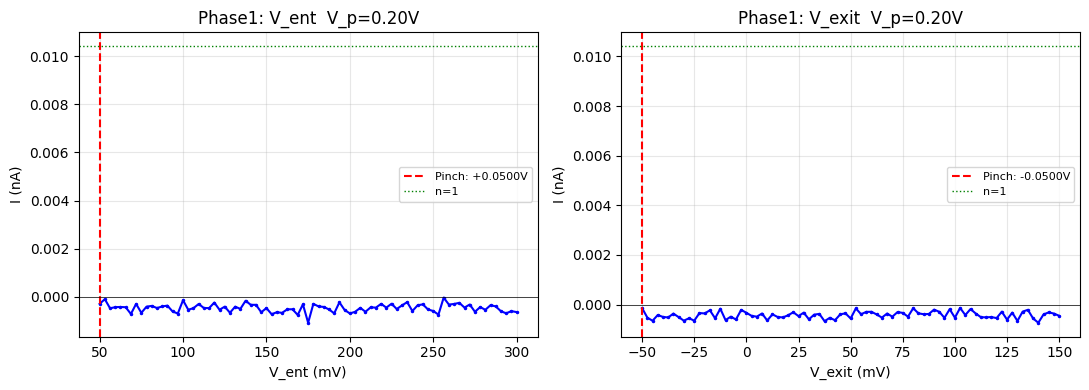


Phase 1 완료
  Pinch-off V_ent:  +0.05000 V
  Pinch-off V_exit: -0.05000 V

⚠️  [실측 전용] 현재 게인: 1e-8 A/V
   Phase 2는 게인 1e-9 A/V 가 필요합니다.
   → 전류 앰프 다이얼을 1e-9 A/V 로 전환하세요.



게인 전환 완료 후 Phase 2 진행하시겠습니까? [y/n]:  y


✅ Phase 2 진행합니다.


In [11]:
# ============================================================
# Cell 11: PHASE 1 실행
# ============================================================

# ▼ 실측 시: 아래 두 줄 주석 처리 (FORCE_SIMULATION=False 로만 동작)
# ▼ 시뮬레이션 시: 경로 설정 후 두 줄 주석 해제
# cfg.SIM_DATA_PATH = '/Users/namkim/Library/CloudStorage/Dropbox/실험일지/2026 BO code/P1_I-Vx-Vn_p0x2mVp_m1mVs_65MHz1dBm_MUXon_2025032131547copy.txt'
# instr = InstrumentController(cfg)   # 반드시 재생성

res1 = run_phase1(instr, cfg)
plot_phase1(res1, cfg)

print()
print('='*65)
print('Phase 1 완료')
print(f'  Pinch-off V_ent:  {res1["pinch_off"]["V_ent"]:+.5f} V')
print(f'  Pinch-off V_exit: {res1["pinch_off"]["V_exit"]:+.5f} V')
print('='*65)
print()
print('⚠️  [실측 전용] 현재 게인: 1e-8 A/V')
print('   Phase 2는 게인 1e-9 A/V 가 필요합니다.')
print('   → 전류 앰프 다이얼을 1e-9 A/V 로 전환하세요.')
print()
while True:
    resp = input('게인 전환 완료 후 Phase 2 진행하시겠습니까? [y/n]: ').strip().lower()
    if resp in ['y','yes']:
        print('✅ Phase 2 진행합니다.')
        break
    elif resp in ['n','no']:
        print('⏹️  실험을 중단합니다.')
        raise SystemExit('사용자 중단')
    else:
        print('   y 또는 n 을 입력해 주세요.')



PHASE 2: BO  [3D (V_ent, V_p, V_exit)]  cost = |n-1|
   Gain: 1e-09 A/V
Bounds:
  V_ent: [+0.0500, +0.3000] V
  V_p: [+0.1000, +0.3000] V
  V_exit: [-0.0500, +0.1500] V

Phase2a: LHS init (25 pts)
-------------------------------------------------------
  Init  1/25: Vent=+0.1323 Vp=+0.2165 Vexit=+0.1111 n=+0.10897  |n-1|=0.89103
  Init  2/25: Vent=+0.2730 Vp=+0.1552 Vexit=+0.0462 n=-0.00720  |n-1|=1.00720
  Init  3/25: Vent=+0.2324 Vp=+0.1577 Vexit=+0.0370 n=+0.04499  |n-1|=0.95501
  Init  4/25: Vent=+0.2155 Vp=+0.2090 Vexit=+0.0626 n=+0.03371  |n-1|=0.96629
  Init  5/25: Vent=+0.2036 Vp=+0.2374 Vexit=+0.0025 n=-0.01419  |n-1|=1.01419
  Init  6/25: Vent=+0.2977 Vp=+0.1916 Vexit=+0.1335 n=-0.03592  |n-1|=1.03592
  Init  7/25: Vent=+0.0917 Vp=+0.1429 Vexit=+0.1199 n=-0.00435  |n-1|=1.00435
  Init  8/25: Vent=+0.1165 Vp=+0.2842 Vexit=+0.0869 n=-0.02097  |n-1|=1.02097
  Init  9/25: Vent=+0.2822 Vp=+0.1704 Vexit=-0.0297 n=-0.00797  |n-1|=1.00797
  Init 10/25: Vent=+0.0596 Vp=+0.2268 Vexit=

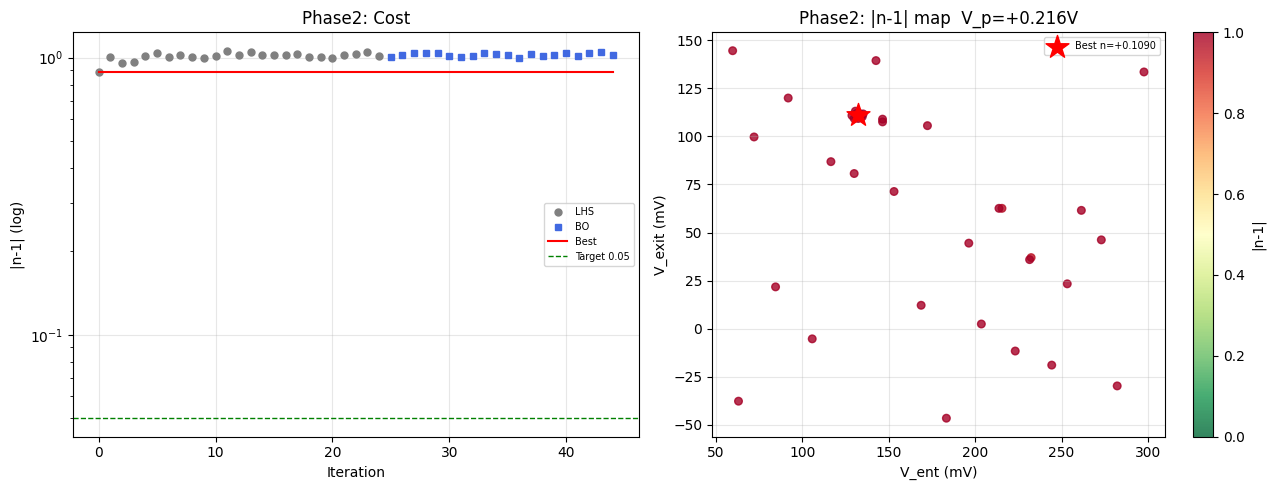


Phase 2 완료


NameError: name 'V_ent' is not defined

In [12]:
# ============================================================
# Cell 12: PHASE 2 실행 — BO (2D sim / 3D HW)
# ============================================================
# 실측 시 V_p 스캔: cfg.V_P_SCAN_IN_HW = True  (기본값)
# 실측 시 V_p 고정: cfg.V_P_SCAN_IN_HW = False

res2 = run_phase2_bo(instr, cfg)
plot_phase2(res2, cfg)

b = res2['best']
print()
print('='*65)
print('Phase 2 완료')
print(f'  Best V_ent:  {b["V_ent"]:+.6f} V')
print(f'  Best V_exit: {b["V_exit"]:+.6f} V')
print(f'  V_p used:    {res2["V_p_used"]:+.6f} V')
print(f'  n =          {b["n"]:+.6f}  |n-1| = {b["n_error"]:.6f}')
print(f'  BO 성공:     {b["n_error"] < cfg.BO_N_TOL}')
print('='*65)
print()

while True:
    resp = input('Phase 3 (확인 맵) 진행하시겠습니까? [y/n]: ').strip().lower()
    if resp in ['y', 'yes']:
        print('✅ Phase 3 진행합니다.')
        break
    elif resp in ['n', 'no']:
        print('⏹️  Phase 3 건너뜀. 펌프맵은 Cell 14를 직접 실행하세요.')
        raise SystemExit('Phase 3 건너뜀')
    else:
        print('   y 또는 n 을 입력해 주세요.')


In [ ]:
# ============================================================
# Cell 13: PHASE 3 실행 — 확인 맵
# ============================================================
res3 = run_phase3_map(instr, res2, cfg)
plot_phase3(res3, cfg)

print()
print('='*65)
print('Phase 3 완료')
print(f'  Plateau 발견: {res3["plateau_found"]}')
print('='*65)
print()

while True:
    resp = input('Phase 4 (펌프맵) 진행하시겠습니까? [y/n]: ').strip().lower()
    if resp in ['y', 'yes']:
        print('✅ Phase 4 진행합니다.')
        break
    elif resp in ['n', 'no']:
        print('⏹️  실험 중단. 저장은 Cell 15를 실행하세요.')
        raise SystemExit('Phase 4 건너뜀')
    else:
        print('   y 또는 n 을 입력해 주세요.')


In [ ]:
# ============================================================
# Cell 14: PHASE 4 실행 — 펌프맵 (6-panel)
# ============================================================
res4 = run_phase4_pumpmap(instr, res2, cfg)
plot_pump_map(res4, cfg)

print()
print('='*65)
print('Phase 4 완료 — 펌프맵 생성')
print(f'  총 측정 횟수: {instr.total_measurements} 회')
print('='*65)
print()

while True:
    resp = input('결과를 저장하시겠습니까? [y/n]: ').strip().lower()
    if resp in ['y', 'yes']:
        print('✅ 저장을 진행합니다.')
        break
    elif resp in ['n', 'no']:
        print('⏹️  저장하지 않고 종료합니다.')
        raise SystemExit('저장 건너뜀')
    else:
        print('   y 또는 n 을 입력해 주세요.')


In [ ]:
# ============================================================
# Cell 15: 저장 + 최종 요약 + 기기 안전 종료
# ============================================================
save_results(res1, res2, res3, res4, cfg)

print()
print('='*65)
print('ALL COMPLETE — v6.3_hw')
b = res2['best']
print(f'  V_ent:   {b["V_ent"]:+.6f} V')
print(f'  V_exit:  {b["V_exit"]:+.6f} V')
print(f'  V_p:     {res2["V_p_used"]:+.6f} V  ({("scanned" if res2["use_3d"] else "fixed")})')
print(f'  n =      {b["n"]:+.6f}  (target 1.0)')
print(f'  |n-1| =  {b["n_error"]:.6f}')
print(f'  총 측정: {instr.total_measurements} 회')
print(f'  출력 폴더: {cfg.output_dir.resolve()}')
print('='*65)
print()

# 기기 안전 종료 — 모든 전압 0V 램프다운 후 연결 해제
instr.close()
